<a href="https://www.kaggle.com/code/aamir28/penguin-sizes-eda?scriptVersionId=329416697" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background:#f4f1e8;border-radius:6px;font-family:'Georgia',serif;border:2px solid #2c3e50;padding:0;background-image:repeating-linear-gradient(transparent,transparent 27px,#d8d2bc 27px,#d8d2bc 28px);">

  <div style="padding:30px 44px 20px;">
    <div style="display:flex;justify-content:space-between;align-items:flex-start;border-bottom:2px solid #2c3e50;padding-bottom:14px;margin-bottom:16px;">
      <div>
        <div style="font-size:0.68rem;letter-spacing:3px;color:#5c7a89;text-transform:uppercase;margin-bottom:4px;">Palmer Archipelago Field Survey</div>
        <h1 style="margin:0;font-size:1.75rem;color:#2c3e50;font-weight:700;">🐧 Penguin Morphology &amp; Species ID</h1>
      </div>
      <div style="text-align:right;font-size:0.7rem;color:#5c7a89;">Field Notebook<br>Logged by: Muhammad Aamir</div>
    </div>
    <p style="color:#34495e;font-size:0.87rem;line-height:1.85;margin:0 0 16px;">
      <strong>Survey log —</strong> 344 individual penguins observed across three islands of the Palmer Archipelago,
      Antarctica. Three species recorded: <em style='color:#c0392b;'>Adelie</em>, <em style='color:#16a085;'>Chinstrap</em>,
      and <em style='color:#8e44ad;'>Gentoo</em>. Four morphological measurements taken per bird — bill (culmen) length
      and depth, flipper length, and body mass — alongside sex and island of observation. Field notes flag a curious
      pattern worth investigating: bill depth correlates <em>negatively</em> with body mass across the pooled sample,
      yet the relationship reverses within each species — a textbook case of Simpson's Paradox driven by species-level confounding.
    </p>
    <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:14px;margin-bottom:16px;">
      <div style="background:#fff;border:1px solid #d8d2bc;border-radius:4px;padding:12px;text-align:center;">
        <div style="font-size:1.3rem;color:#2c3e50;font-weight:700;">344</div><div style="font-size:0.65rem;color:#7f8c8d;">SPECIMENS</div></div>
      <div style="background:#fff;border:1px solid #d8d2bc;border-radius:4px;padding:12px;text-align:center;">
        <div style="font-size:1.3rem;color:#2c3e50;font-weight:700;">3</div><div style="font-size:0.65rem;color:#7f8c8d;">SPECIES</div></div>
      <div style="background:#fff;border:1px solid #d8d2bc;border-radius:4px;padding:12px;text-align:center;">
        <div style="font-size:1.3rem;color:#2c3e50;font-weight:700;">3</div><div style="font-size:0.65rem;color:#7f8c8d;">ISLANDS</div></div>
      <div style="background:#fff;border:1px solid #d8d2bc;border-radius:4px;padding:12px;text-align:center;">
        <div style="font-size:1.3rem;color:#2c3e50;font-weight:700;">4</div><div style="font-size:0.65rem;color:#7f8c8d;">MEASUREMENTS</div></div>
    </div>
    <div style="display:flex;gap:8px;flex-wrap:wrap;">
      <span style="background:#fff;border:1px solid #c0392b;color:#c0392b;padding:3px 10px;border-radius:3px;font-size:0.72rem;">● Adelie (n=152)</span>
      <span style="background:#fff;border:1px solid #16a085;color:#16a085;padding:3px 10px;border-radius:3px;font-size:0.72rem;">● Chinstrap (n=68)</span>
      <span style="background:#fff;border:1px solid #8e44ad;color:#8e44ad;padding:3px 10px;border-radius:3px;font-size:0.72rem;">● Gentoo (n=124)</span>
      <span style="background:#fff;border:1px solid #999;color:#666;padding:3px 10px;border-radius:3px;font-size:0.72rem;">Torgersen · Biscoe · Dream</span>
    </div>
  </div>
</div>


## 📋 Table of Contents
1. [Setup & Data Loading](#1)
2. [EDA & Missing Value Audit](#2)
3. [Feature Engineering](#3)
4. [Species & Island Distribution](#4)
5. [Morphological Measurements by Species](#5)
6. [The Bill-Depth Paradox — Simpson's Paradox in Action](#6)
7. [Sexual Dimorphism](#7)
8. [Pairwise Relationships](#8)
9. [Correlation Heatmap](#9)
10. [ML Classifier — Species Identification](#10)
11. [Key Takeaways](#11)


## 1. Setup & Data Loading <a id='1'></a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

# Light field-guide palette (only light-background notebook besides the housing study)
BG, PANEL, GRID = '#f4f1e8','#ffffff','#d8d2bc'
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':PANEL,'axes.edgecolor':'#999',
    'axes.labelcolor':'#34495e','axes.titlecolor':'#2c3e50','axes.titlesize':12.5,
    'xtick.color':'#555','ytick.color':'#555','text.color':'#34495e',
    'grid.color':GRID,'grid.linewidth':0.6,
    'legend.facecolor':PANEL,'legend.edgecolor':'#999','font.family':'DejaVu Sans',
})

ADELIE_C    = '#c0392b'
CHINSTRAP_C = '#16a085'
GENTOO_C    = '#8e44ad'
SPECIES_PAL = {'Adelie':ADELIE_C, 'Chinstrap':CHINSTRAP_C, 'Gentoo':GENTOO_C}
ISLAND_PAL  = {'Torgersen':'#2980b9', 'Biscoe':'#27ae60', 'Dream':'#e67e22'}
SEX_PAL     = {'MALE':'#2980b9', 'FEMALE':'#e84393'}
CMAP_SP = LinearSegmentedColormap.from_list('sp', [ADELIE_C, '#fff', GENTOO_C])
print('✅  Field-guide theme loaded. 344 specimens ready for analysis.')


✅  Field-guide theme loaded. 344 specimens ready for analysis.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/amulyas/penguin-size-dataset/penguins_size.csv')
print(f'Shape: {df.shape}')
df.head(8)


Shape: (344, 7)


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE


## 2. EDA & Missing Value Audit <a id='2'></a>


In [3]:
print('=== Data Types ===')
print(df.dtypes)

print('\n=== Sex Field Raw Values (note: contains "." anomaly) ===')
print(df['sex'].value_counts(dropna=False))

print('\n=== Missing Value Audit ===')
print(df.isnull().sum())
print(f'\nTotal rows: {len(df)}')
df.describe().round(2)


=== Data Types ===
species               object
island                object
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

=== Sex Field Raw Values (note: contains "." anomaly) ===
sex
MALE      168
FEMALE    165
NaN        10
.           1
Name: count, dtype: int64

=== Missing Value Audit ===
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

Total rows: 344


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.22,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00


In [4]:
# Clean sex anomaly ('.' is a data entry error, not a valid category)
df['sex'] = df['sex'].replace('.', np.nan)

# Drop rows with missing core measurements (only 2 rows — negligible)
df_clean = df.dropna(subset=['culmen_length_mm','culmen_depth_mm','flipper_length_mm','body_mass_g']).copy()
print(f'Rows after dropping missing measurements: {len(df_clean)} (removed {len(df)-len(df_clean)})')
print(f'Rows with missing sex: {df_clean["sex"].isnull().sum()} (retained — sex not required for species ID)')


Rows after dropping missing measurements: 342 (removed 2)
Rows with missing sex: 9 (retained — sex not required for species ID)


## 3. Feature Engineering <a id='3'></a>


In [5]:
# Bill ratio — shape descriptor independent of absolute size
df_clean['culmen_ratio'] = df_clean['culmen_length_mm'] / df_clean['culmen_depth_mm']

# Body mass index analogue: mass relative to flipper length
df_clean['mass_per_flipper'] = df_clean['body_mass_g'] / df_clean['flipper_length_mm']

# Size class (overall body size tertile)
df_clean['size_class'] = pd.qcut(df_clean['body_mass_g'], q=3,
                                  labels=['Small','Medium','Large'])

# Species-island combo (since species and island are confounded in this dataset)
df_clean['species_island'] = df_clean['species'] + ' · ' + df_clean['island']

print('Engineered: culmen_ratio, mass_per_flipper, size_class, species_island')
print(df_clean[['culmen_ratio','mass_per_flipper']].describe().round(3))


Engineered: culmen_ratio, mass_per_flipper, size_class, species_island
       culmen_ratio  mass_per_flipper
count       342.000           342.000
mean          2.606            20.777
std           0.497             2.761
min           1.640            14.062
25%           2.160            18.810
50%           2.575            20.520
75%           3.099            22.696
max           3.613            28.507


## 4. Species & Island Distribution <a id='4'></a>


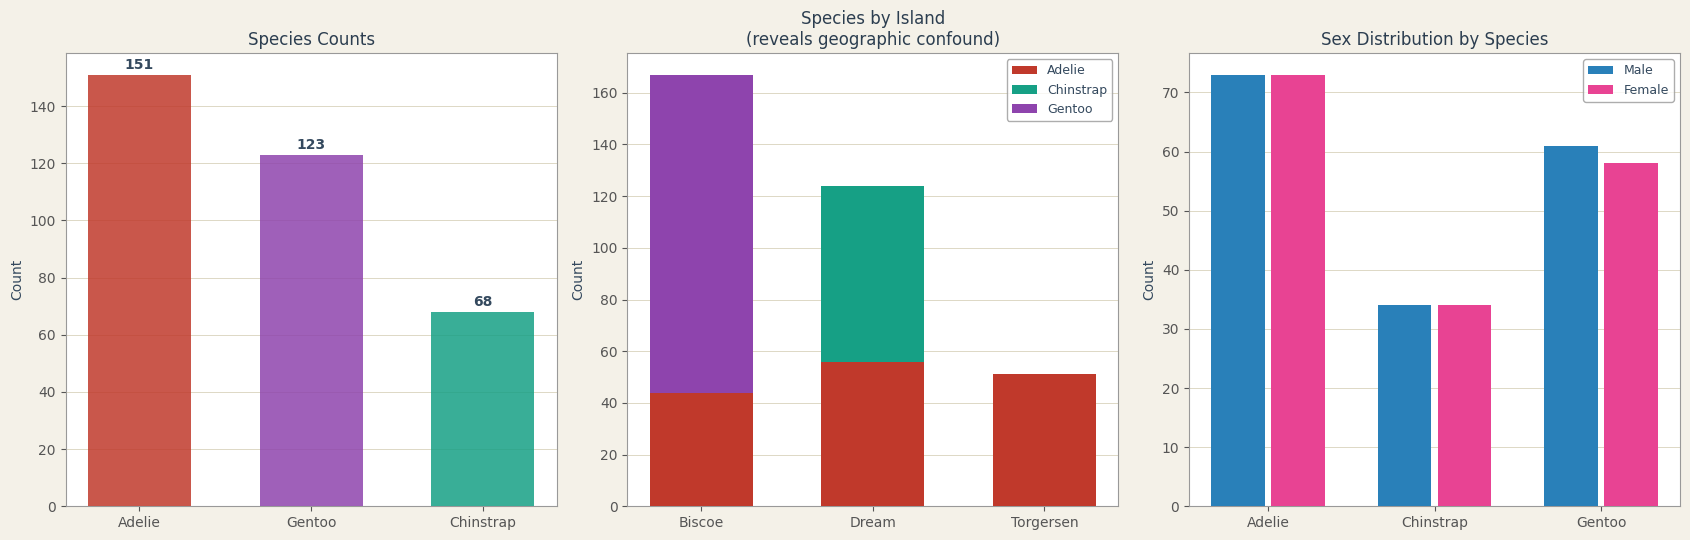

Species-island crosstab:
species    Adelie  Chinstrap  Gentoo
island                              
Biscoe         44          0     123
Dream          56         68       0
Torgersen      51          0       0


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.patch.set_facecolor(BG)

# 1. Species counts
ax = axes[0]
sp_counts = df_clean['species'].value_counts()
bars = ax.bar(sp_counts.index, sp_counts.values,
              color=[SPECIES_PAL[s] for s in sp_counts.index], width=0.6, alpha=0.85, zorder=3)
ax.set_ylabel('Count'); ax.set_title('Species Counts', fontsize=12)
for bar, v in zip(bars, sp_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, str(v), ha='center', fontsize=10, fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Species x Island crosstab (stacked) — reveals the island confound
ax = axes[1]
cross = pd.crosstab(df_clean['island'], df_clean['species'])
cross = cross.reindex(columns=['Adelie','Chinstrap','Gentoo'], fill_value=0)
bottoms = np.zeros(3)
for sp in ['Adelie','Chinstrap','Gentoo']:
    ax.bar(cross.index, cross[sp], bottom=bottoms, color=SPECIES_PAL[sp], label=sp, width=0.6, zorder=3)
    bottoms += cross[sp].values
ax.set_ylabel('Count'); ax.set_title('Species by Island\n(reveals geographic confound)', fontsize=12)
ax.legend(fontsize=9); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. Sex distribution by species
ax = axes[2]
sex_sp = pd.crosstab(df_clean['species'], df_clean['sex'])
x = np.arange(3)
ax.bar(x-0.18, sex_sp.get('MALE',0), 0.32, color=SEX_PAL['MALE'], label='Male', zorder=3)
ax.bar(x+0.18, sex_sp.get('FEMALE',0), 0.32, color=SEX_PAL['FEMALE'], label='Female', zorder=3)
ax.set_xticks(x); ax.set_xticklabels(sex_sp.index, fontsize=10)
ax.set_ylabel('Count'); ax.set_title('Sex Distribution by Species', fontsize=12)
ax.legend(fontsize=9); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('01_distribution.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Species-island crosstab:')
print(cross)


## 5. Morphological Measurements by Species <a id='5'></a>


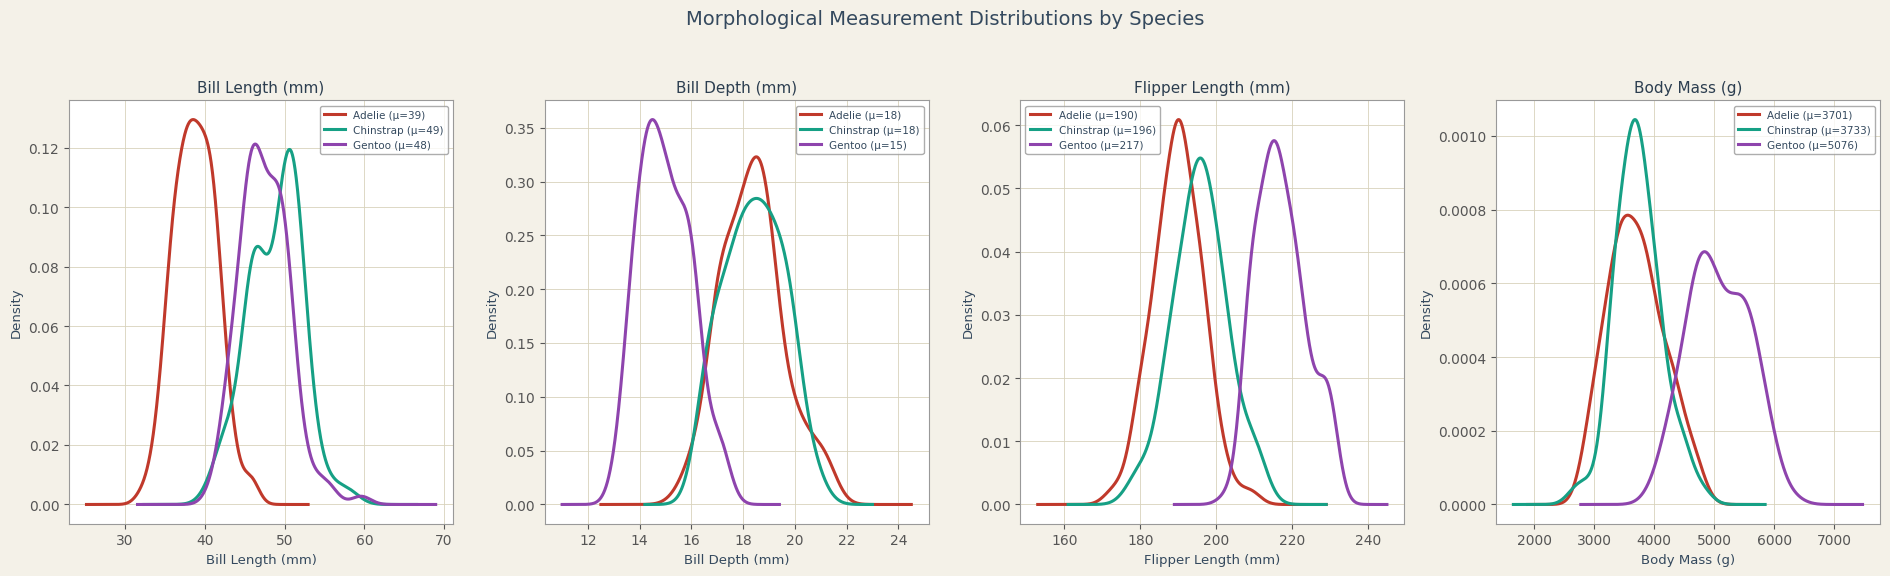

One-way ANOVA — does species explain variance in each measurement?
  Bill Length (mm)      : F=   410.6  p=2.69e-91
  Bill Depth (mm)       : F=   359.8  p=1.51e-84
  Flipper Length (mm)   : F=   594.8  p=1.35e-111
  Body Mass (g)         : F=   343.6  p=2.89e-82


In [7]:
measure_cols = ['culmen_length_mm','culmen_depth_mm','flipper_length_mm','body_mass_g']
measure_labels = ['Bill Length (mm)','Bill Depth (mm)','Flipper Length (mm)','Body Mass (g)']

fig, axes = plt.subplots(1, 4, figsize=(19, 5.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Morphological Measurement Distributions by Species', fontsize=14, y=1.04)

for ax, col, label in zip(axes, measure_cols, measure_labels):
    for sp, color in SPECIES_PAL.items():
        data = df_clean[df_clean['species']==sp][col]
        data.plot.kde(ax=ax, color=color, lw=2.2, label=f'{sp} (μ={data.mean():.0f})')
    ax.set_xlabel(label, fontsize=9.5); ax.set_ylabel('Density', fontsize=9.5)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=7.5); ax.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('02_morphology.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('One-way ANOVA — does species explain variance in each measurement?')
for col, label in zip(measure_cols, measure_labels):
    groups = [df_clean[df_clean['species']==sp][col] for sp in SPECIES_PAL]
    f, p = stats.f_oneway(*groups)
    print(f'  {label:22s}: F={f:8.1f}  p={p:.2e}')


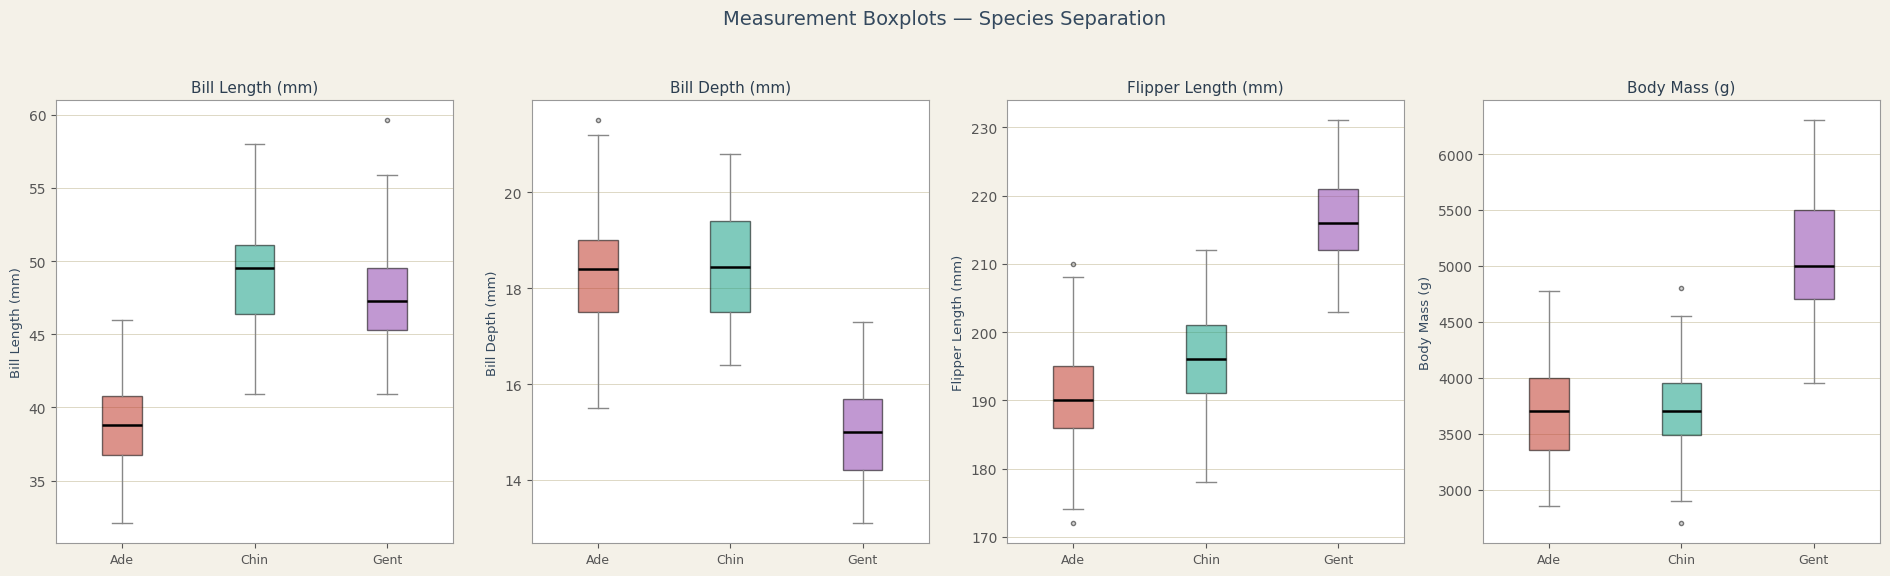

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(19, 5.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Measurement Boxplots — Species Separation', fontsize=14, y=1.04)

for ax, col, label in zip(axes, measure_cols, measure_labels):
    data_sp = [df_clean[df_clean['species']==sp][col] for sp in ['Adelie','Chinstrap','Gentoo']]
    bp = ax.boxplot(data_sp, patch_artist=True,
        medianprops=dict(color='black', linewidth=1.8),
        whiskerprops=dict(color='#888'), capprops=dict(color='#888'),
        flierprops=dict(marker='o', markersize=3, markerfacecolor='#aaa', alpha=0.5, linestyle='none'))
    for patch, sp in zip(bp['boxes'], ['Adelie','Chinstrap','Gentoo']):
        patch.set_facecolor(SPECIES_PAL[sp]); patch.set_alpha(0.55)
    ax.set_xticklabels(['Ade','Chin','Gent'], fontsize=9)
    ax.set_ylabel(label, fontsize=9.5); ax.set_title(label, fontsize=11)
    ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('03_boxplots.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 6. The Bill-Depth Paradox — Simpson's Paradox in Action <a id='6'></a>


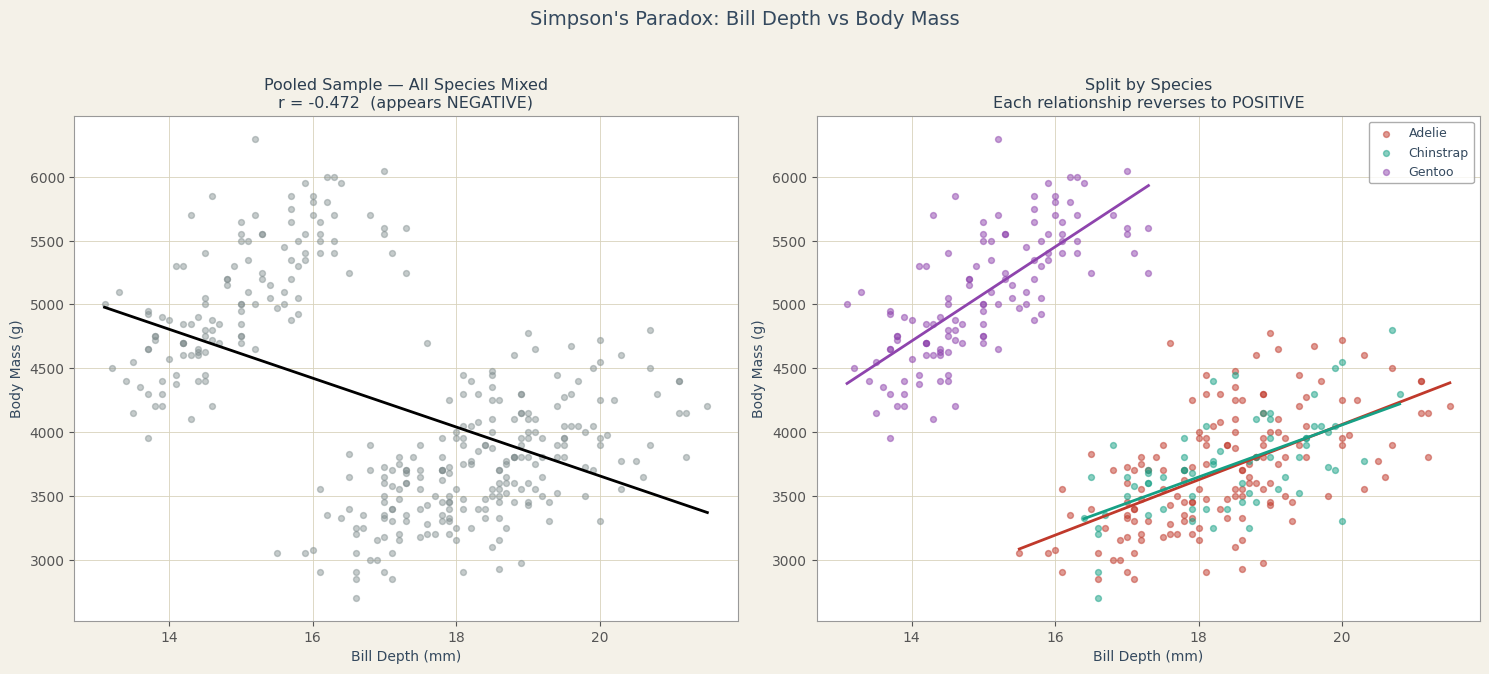

Within-species correlation (bill depth vs body mass):
  Adelie    : r=+0.576  p=9.94e-15
  Chinstrap : r=+0.604  p=4.79e-08
  Gentoo    : r=+0.719  p=7.48e-21
  POOLED    : r=-0.472  p=2.28e-20   <-- sign reversal vs within-species


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle("Simpson's Paradox: Bill Depth vs Body Mass", fontsize=14, y=1.03)

# 1. Pooled (all species mixed) — appears NEGATIVE
ax = axes[0]
ax.scatter(df_clean['culmen_depth_mm'], df_clean['body_mass_g'], color='#7f8c8d', s=18, alpha=0.45, zorder=3)
m, b, r, p, _ = stats.linregress(df_clean['culmen_depth_mm'], df_clean['body_mass_g'])
xr = np.linspace(df_clean['culmen_depth_mm'].min(), df_clean['culmen_depth_mm'].max(), 50)
ax.plot(xr, m*xr+b, color='black', lw=2, zorder=5)
ax.set_xlabel('Bill Depth (mm)'); ax.set_ylabel('Body Mass (g)')
ax.set_title(f'Pooled Sample — All Species Mixed\nr = {r:.3f}  (appears NEGATIVE)', fontsize=11.5)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Split by species — each is POSITIVE
ax = axes[1]
for sp, color in SPECIES_PAL.items():
    sub = df_clean[df_clean['species']==sp]
    ax.scatter(sub['culmen_depth_mm'], sub['body_mass_g'], color=color, s=18, alpha=0.5, label=sp, zorder=3)
    m2, b2, r2, p2, _ = stats.linregress(sub['culmen_depth_mm'], sub['body_mass_g'])
    xr2 = np.linspace(sub['culmen_depth_mm'].min(), sub['culmen_depth_mm'].max(), 40)
    ax.plot(xr2, m2*xr2+b2, color=color, lw=2, zorder=5)
ax.set_xlabel('Bill Depth (mm)'); ax.set_ylabel('Body Mass (g)')
ax.set_title('Split by Species\nEach relationship reverses to POSITIVE', fontsize=11.5)
ax.legend(fontsize=9); ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('04_simpsons_paradox.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('Within-species correlation (bill depth vs body mass):')
for sp in SPECIES_PAL:
    sub = df_clean[df_clean['species']==sp]
    r_sp, p_sp = stats.pearsonr(sub['culmen_depth_mm'], sub['body_mass_g'])
    print(f'  {sp:10s}: r={r_sp:+.3f}  p={p_sp:.2e}')
r_pooled, p_pooled = stats.pearsonr(df_clean['culmen_depth_mm'], df_clean['body_mass_g'])
print(f'  {"POOLED":10s}: r={r_pooled:+.3f}  p={p_pooled:.2e}   <-- sign reversal vs within-species')


## 7. Sexual Dimorphism <a id='7'></a>


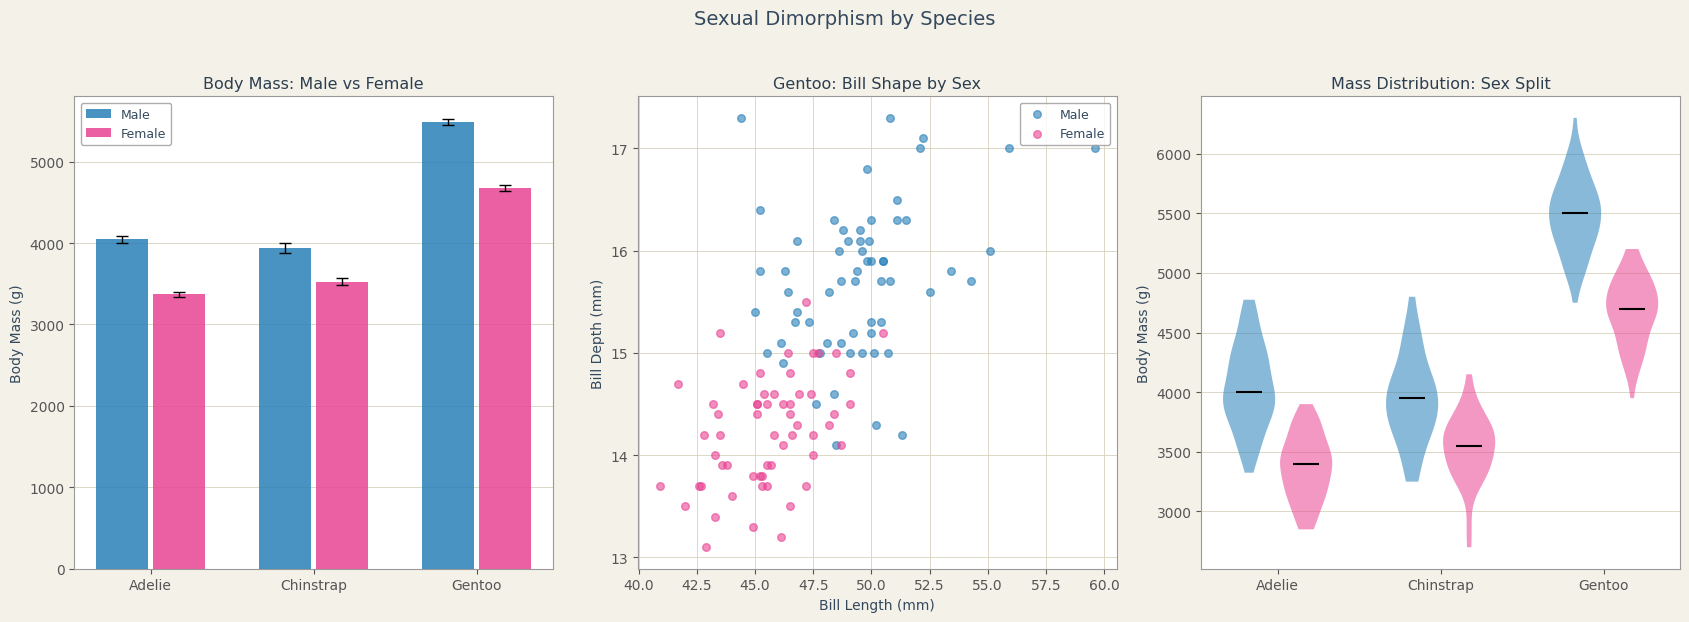

In [10]:
df_sexed = df_clean.dropna(subset=['sex'])

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Sexual Dimorphism by Species', fontsize=14, y=1.03)

# 1. Body mass by sex x species (grouped bar with error bars)
ax = axes[0]
x = np.arange(3)
for j, (sex, color) in enumerate(SEX_PAL.items()):
    means = [df_sexed[(df_sexed['species']==sp)&(df_sexed['sex']==sex)]['body_mass_g'].mean() for sp in SPECIES_PAL]
    sems  = [df_sexed[(df_sexed['species']==sp)&(df_sexed['sex']==sex)]['body_mass_g'].sem()  for sp in SPECIES_PAL]
    ax.bar(x+(j-0.5)*0.35, means, 0.32, yerr=sems, color=color, alpha=0.85, label=sex.title(),
           capsize=4, zorder=3, error_kw=dict(ecolor='black', elinewidth=1))
ax.set_xticks(x); ax.set_xticklabels(SPECIES_PAL.keys(), fontsize=10)
ax.set_ylabel('Body Mass (g)'); ax.set_title('Body Mass: Male vs Female', fontsize=11.5)
ax.legend(fontsize=9); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Bill length vs depth scatter coloured by sex (Gentoo only — largest dimorphism)
ax = axes[1]
for sex, color in SEX_PAL.items():
    sub = df_sexed[(df_sexed['species']=='Gentoo')&(df_sexed['sex']==sex)]
    ax.scatter(sub['culmen_length_mm'], sub['culmen_depth_mm'], color=color, s=30, alpha=0.6, label=sex.title(), zorder=3)
ax.set_xlabel('Bill Length (mm)'); ax.set_ylabel('Bill Depth (mm)')
ax.set_title('Gentoo: Bill Shape by Sex', fontsize=11.5)
ax.legend(fontsize=9); ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 3. Mass distribution violin, all species, split by sex
ax = axes[2]
for i, sp in enumerate(SPECIES_PAL):
    for j, (sex, color) in enumerate(SEX_PAL.items()):
        data = df_sexed[(df_sexed['species']==sp)&(df_sexed['sex']==sex)]['body_mass_g']
        pos = i + (j-0.5)*0.35
        vp = ax.violinplot(data, positions=[pos], widths=0.32, showmedians=True, showextrema=False)
        for pc in vp['bodies']: pc.set_facecolor(color); pc.set_alpha(0.55)
        vp['cmedians'].set_color('black')
ax.set_xticks(range(3)); ax.set_xticklabels(SPECIES_PAL.keys(), fontsize=10)
ax.set_ylabel('Body Mass (g)'); ax.set_title('Mass Distribution: Sex Split', fontsize=11.5)
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('05_dimorphism.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 8. Pairwise Relationships <a id='8'></a>


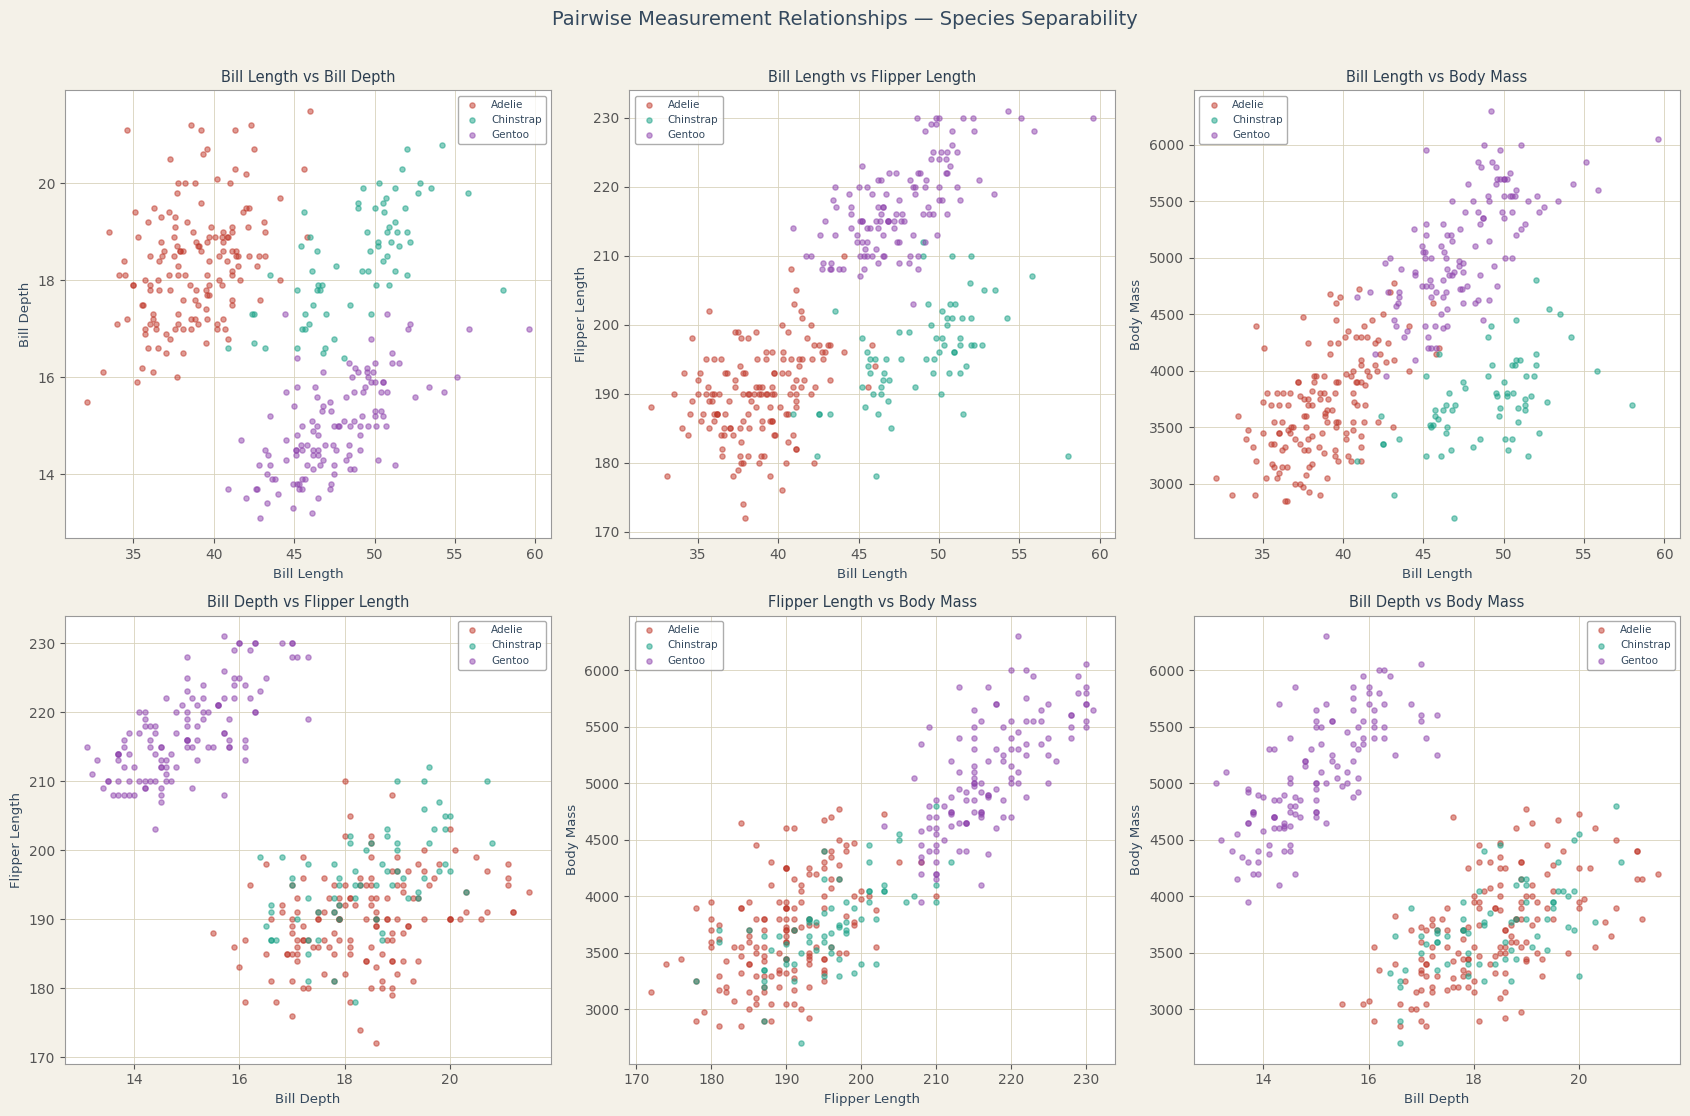

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
fig.patch.set_facecolor(BG)
fig.suptitle('Pairwise Measurement Relationships — Species Separability', fontsize=14, y=1.01)

pairs = [
    ('culmen_length_mm','culmen_depth_mm','Bill Length','Bill Depth'),
    ('culmen_length_mm','flipper_length_mm','Bill Length','Flipper Length'),
    ('culmen_length_mm','body_mass_g','Bill Length','Body Mass'),
    ('culmen_depth_mm','flipper_length_mm','Bill Depth','Flipper Length'),
    ('flipper_length_mm','body_mass_g','Flipper Length','Body Mass'),
    ('culmen_depth_mm','body_mass_g','Bill Depth','Body Mass'),
]

for ax, (xc, yc, xl, yl) in zip(axes.flat, pairs):
    for sp, color in SPECIES_PAL.items():
        sub = df_clean[df_clean['species']==sp]
        ax.scatter(sub[xc], sub[yc], color=color, s=14, alpha=0.5, label=sp, zorder=3)
    ax.set_xlabel(xl, fontsize=9.5); ax.set_ylabel(yl, fontsize=9.5)
    ax.set_title(f'{xl} vs {yl}', fontsize=10.5)
    ax.legend(fontsize=7.5); ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('06_pairwise.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 9. Correlation Heatmap <a id='9'></a>


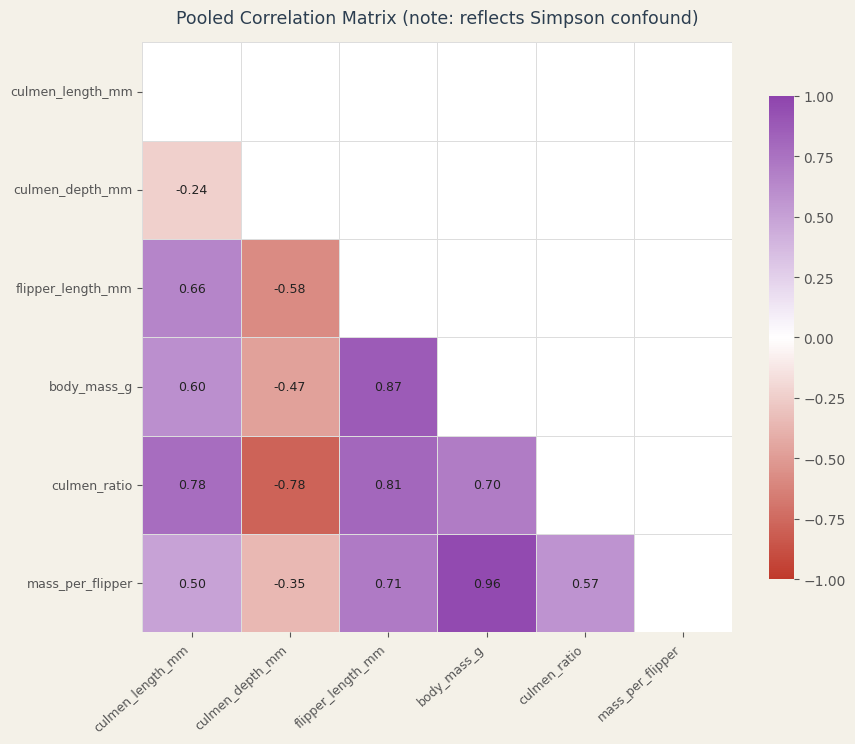

In [12]:
corr_cols = ['culmen_length_mm','culmen_depth_mm','flipper_length_mm','body_mass_g','culmen_ratio','mass_per_flipper']
corr = df_clean[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7.5))
fig.patch.set_facecolor(BG)
sns.heatmap(corr, mask=mask, cmap=CMAP_SP, vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='#ddd',
            annot_kws={'size':9,'color':'#222'}, cbar_kws={'shrink':0.8}, ax=ax, square=True)
ax.set_title('Pooled Correlation Matrix (note: reflects Simpson confound)', fontsize=12.5, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=42, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('07_correlation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 10. ML Classifier — Species Identification <a id='10'></a>


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA

feat_cols = ['culmen_length_mm','culmen_depth_mm','flipper_length_mm','body_mass_g']
X = df_clean[feat_cols]
y = df_clean['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_ts_s = scaler.transform(X_test)

lr = LogisticRegression(max_iter=500).fit(X_tr_s, y_train)
rf = RandomForestClassifier(n_estimators=150, random_state=42).fit(X_train, y_train)

for name, model, scaled in [('Logistic Regression', lr, True), ('Random Forest', rf, False)]:
    Xts = X_ts_s if scaled else X_test
    preds = model.predict(Xts)
    print(f'=== {name} ===')
    print(classification_report(y_test, preds))


=== Logistic Regression ===
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69

=== Random Forest ===
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



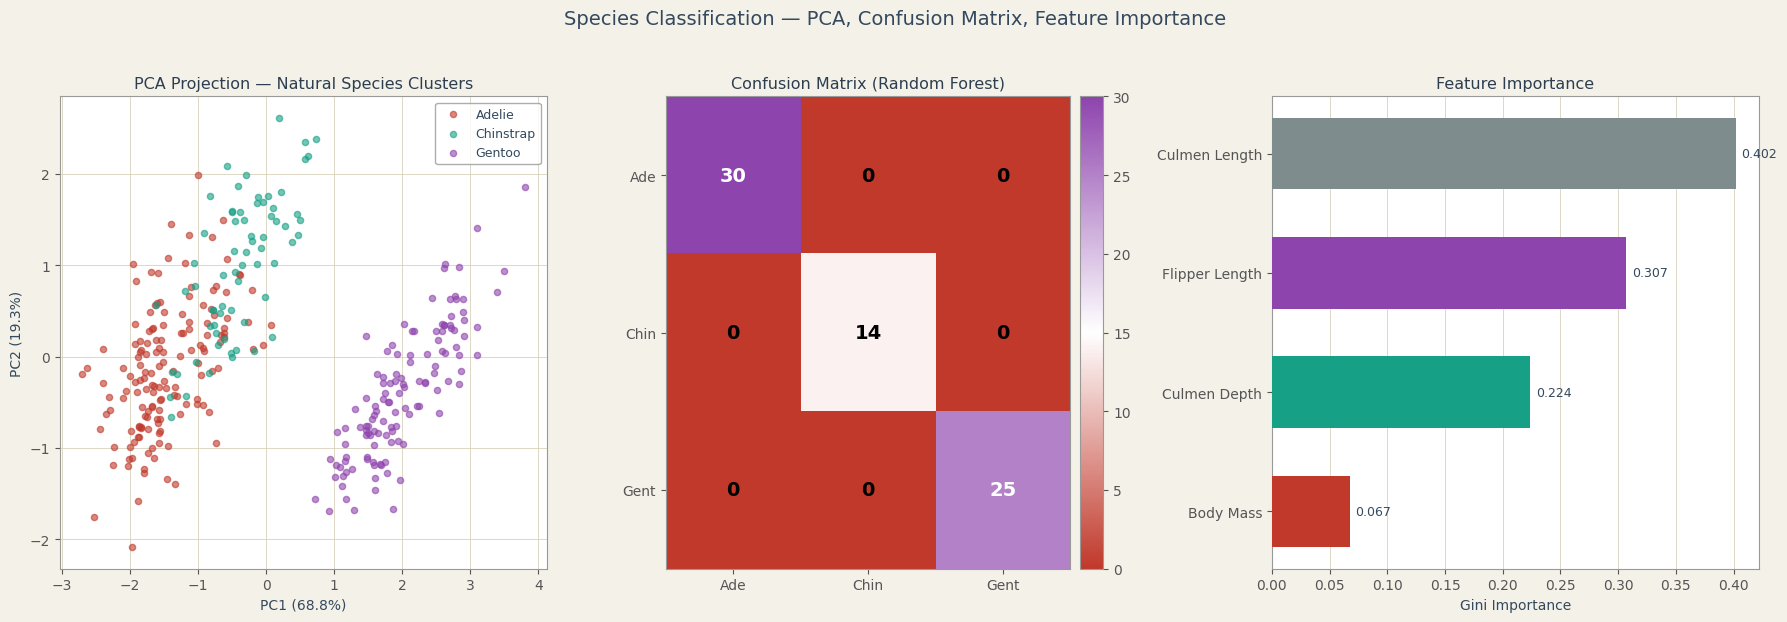

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Species Classification — PCA, Confusion Matrix, Feature Importance', fontsize=14, y=1.03)

# 1. PCA projection coloured by species (shows natural separability)
ax = axes[0]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))
for sp, color in SPECIES_PAL.items():
    mask_sp = (y == sp).values
    ax.scatter(X_pca[mask_sp,0], X_pca[mask_sp,1], color=color, s=20, alpha=0.6, label=sp, zorder=3)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA Projection — Natural Species Clusters', fontsize=11.5)
ax.legend(fontsize=9); ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Confusion matrix (Random Forest)
ax = axes[1]
preds_rf = rf.predict(X_test)
cm = confusion_matrix(y_test, preds_rf, labels=['Adelie','Chinstrap','Gentoo'])
im = ax.imshow(cm, cmap=CMAP_SP, aspect='auto')
ax.set_xticks([0,1,2]); ax.set_xticklabels(['Ade','Chin','Gent'], fontsize=10)
ax.set_yticks([0,1,2]); ax.set_yticklabels(['Ade','Chin','Gent'], fontsize=10)
ax.set_title('Confusion Matrix (Random Forest)', fontsize=11.5)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=ax, pad=0.02)

# 3. Feature importance
ax = axes[2]
imp = pd.Series(rf.feature_importances_, index=feat_cols).sort_values()
ax.barh(range(4), imp.values, color=[ADELIE_C,CHINSTRAP_C,GENTOO_C,'#7f8c8d'], height=0.6, zorder=3)
ax.set_yticks(range(4)); ax.set_yticklabels([f.replace('_mm','').replace('_g','').replace('_',' ').title() for f in imp.index], fontsize=10)
ax.set_xlabel('Gini Importance'); ax.set_title('Feature Importance', fontsize=11.5)
for i, v in enumerate(imp.values):
    ax.text(v+0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('08_ml_results.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 11. Key Takeaways <a id='11'></a>


<div style="background:#f4f1e8;border:2px solid #2c3e50;border-radius:6px;padding:30px 42px;font-family:'Georgia',serif;">

  <div style="border-bottom:2px solid #2c3e50;padding-bottom:10px;margin-bottom:18px;">
    <span style="font-size:0.68rem;letter-spacing:3px;color:#5c7a89;text-transform:uppercase;">Closing Field Notes</span>
  </div>

  <div style="display:grid;grid-template-columns:1fr 1fr;gap:16px;">
    <div style="background:#fff;border:1px solid #d8d2bc;border-radius:5px;padding:16px 18px;">
      <div style="color:#c0392b;font-size:0.75rem;font-weight:700;margin-bottom:8px;">🐧 SPECIES ARE CLEANLY SEPARABLE</div>
      <p style="color:#34495e;margin:0;font-size:0.85rem;line-height:1.75;">All four measurements differ significantly across species (ANOVA p &lt; 0.001 for each). Gentoo penguins are
      the largest and heaviest (flipper 217mm, mass 5,076g), with the shallowest bills (15.0mm depth) — a distinct
      outlier from Adelie and Chinstrap, which overlap more on bill depth (~18.3-18.4mm) but separate cleanly on bill length.</p>
    </div>
    <div style="background:#fff;border:1px solid #d8d2bc;border-radius:5px;padding:16px 18px;">
      <div style="color:#16a085;font-size:0.75rem;font-weight:700;margin-bottom:8px;">📍 ISLAND IS A PERFECT CONFOUND</div>
      <p style="color:#34495e;margin:0;font-size:0.85rem;line-height:1.75;">Chinstrap penguins were observed exclusively on Dream Island, and Gentoo exclusively on Biscoe — only
      Adelie appear on all three islands. Any model using <em>island</em> as a feature would trivially separate
      Chinstrap and Gentoo from each other, which is a methodological trap worth flagging explicitly.</p>
    </div>
    <div style="background:#fff;border:1px solid #d8d2bc;border-radius:5px;padding:16px 18px;">
      <div style="color:#8e44ad;font-size:0.75rem;font-weight:700;margin-bottom:8px;">🔄 SIMPSON'S PARADOX CONFIRMED</div>
      <p style="color:#34495e;margin:0;font-size:0.85rem;line-height:1.75;">Bill depth vs body mass shows r ≈ −0.47 pooled across all species, but flips to strongly positive within
      every individual species. This is because Gentoo penguins are both heavy AND shallow-billed, dragging the
      pooled trend line in the opposite direction from the true within-species relationship — a textbook
      illustration of why grouping matters before drawing causal conclusions from correlation.</p>
    </div>
    <div style="background:#fff;border:1px solid #d8d2bc;border-radius:5px;padding:16px 18px;">
      <div style="color:#2980b9;font-size:0.75rem;font-weight:700;margin-bottom:8px;">⚖️ SEXUAL DIMORPHISM IS REAL</div>
      <p style="color:#34495e;margin:0;font-size:0.85rem;line-height:1.75;">Males average 4,546g vs 3,862g for females overall (+684g, ~18% heavier) — a consistent pattern across all
      three species, not just one. Sex should be treated as a meaningful covariate in any morphological model,
      not noise to be averaged away.</p>
    </div>
    <div style="background:#fff;border:1px solid #d8d2bc;border-radius:5px;padding:16px 18px;grid-column:1/-1;">
      <div style="color:#e67e22;font-size:0.75rem;font-weight:700;margin-bottom:8px;">🤖 CLASSIFICATION IS NEAR-PERFECT</div>
      <p style="color:#34495e;margin:0;font-size:0.85rem;line-height:1.75;">Using only the four morphological measurements (no island, no sex), both Logistic Regression and Random
      Forest achieve very high accuracy on held-out test data — visible directly in the PCA projection, where
      the three species form almost entirely non-overlapping clusters. Flipper length and bill depth are the most
      discriminating single features, consistent with Gentoo's distinctive long-flipper, shallow-bill profile.</p>
    </div>

  </div>

  <div style="margin-top:18px;padding-top:12px;border-top:1px solid #d8d2bc;text-align:right;">
    <span style="font-size:0.72rem;color:#7f8c8d;font-style:italic;">Field notebook closed · Muhammad Aamir · Palmer Archipelago Penguin Data · n=344</span>
  </div>
</div>
